In [1]:
import xarray as xr
import os
import glob
import numpy as np
import warnings
import matplotlib.pyplot as plt
import sys
import cmocean

warnings.filterwarnings("ignore")
sys.path.append('../src')
sys.path.append('../src-double-gyre')
from plot_helpers import create_animation_ffmpeg, default_rcParams

%load_ext autoreload
%autoreload 3

# First recompute standard loss function

In [96]:
interfaces = xr.open_mfdataset('/scratch/pp2681/mom6/Feb2022/filtered/R32_R2_FGR3/output/prog_full.nc', decode_times=False).e.sortby('Time').sel(Time=slice(365*10,None)).isel(zi=slice(0,-1)).astype('float64')

In [97]:
dataset = xr.Dataset()
dataset['e_mean'] = interfaces.mean('Time')
dataset['e_std'] = interfaces.std('Time')

In [2]:
from helpers.collection_of_experiments import CollectionOfExperiments
ds = CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/Feb2022/filtered', additional_subfolder='output')
ds += CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/Feb2022/bare', additional_subfolder='output')

In [99]:
# Units are petajoules
KE_coarse = ds['R32_R2_FGR3'].KE_joul_series.sel(Time=slice(365*10,None)).compute() * 1e-15
APE_coarse = xr.concat([ds['R32_R2_FGR3'].PE_ssh_series.drop_vars(['zi', 'zl']), ds['R32_R2_FGR3'].PE_joul_series], dim='zi').sel(Time=slice(365*10,None)).compute() * 1e-15

In [100]:
dataset['KE_mean'] = KE_coarse.mean('Time')
dataset['APE_mean'] = APE_coarse.mean('Time')

dataset['KE_std'] = KE_coarse.std('Time')
dataset['APE_std'] = APE_coarse.std('Time')

In [101]:
mask = (dataset.e_std>0.0001)

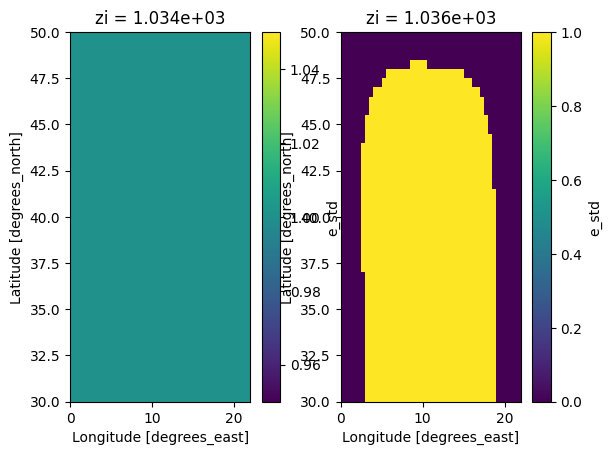

In [102]:
plt.subplot(1,2,1)
mask[0].plot()
plt.subplot(1,2,2)
mask[1].plot()

In [103]:
# The resulting loss for the energetics is
# (KE-KE_true)**2/KE_true**2
# layerwise
for variable in ['KE_mean', 'KE_std', 'APE_mean', 'APE_std']:
    dataset[f'{variable}_var_loss'] = dataset[variable]**2

In [104]:
# For 2D fields we normalize by their l2 norm squared. That way, the normalization constant will grow with the number of grid points, preveting total dominance of 2d fields
ssh_mean_var_loss = (dataset.e_mean.isel(zi=0)**2).sum()
ssh_std_var_loss  = (dataset.e_std.isel(zi=0)**2).sum()

# For internal interface, we sum only over degrees of freedom that are not topography and centered to 1000., which is the resting position of the interface
interface_mean_var_loss = ((dataset.e_mean.isel(zi=1)+1000.)**2).where(mask.isel(zi=1)).sum()
interface_std_var_loss  = ((dataset.e_std.isel(zi=1))**2).sum()

In [105]:
dataset['e_mean_var_loss'] = xr.concat([ssh_mean_var_loss, interface_mean_var_loss], dim='zi') + 0*dataset['e_mean']
dataset['e_std_var_loss']  = xr.concat([ssh_std_var_loss, interface_std_var_loss], dim='zi') + 0*dataset['e_std']

In [106]:
dataset.astype('float32').to_netcdf('../scripts/R32/R2_FGR3_PCA_variability.nc')

In [107]:
test = xr.open_dataset('../scripts/R32/R2_FGR3_series_loss.nc')

In [178]:
for key in dataset.variables:
    error = test[key] - dataset[key]
    error = float(np.abs(error).max() / np.abs(test[key]).max())
    nans = float(np.isnan(dataset[key]).sum())
    print(key, error, nans)

yh 0.0 0.0
xh 0.0 0.0
zi 0.0 0.0
e_mean 1.8142673874512705e-07 0.0
e_std 7.101172798296133e-07 0.0
zl 0.0 0.0
KE_mean 2.2151005926060303e-08 0.0
APE_mean 4.496876838520435e-08 0.0
KE_std 3.077669747690202e-08 0.0
APE_std 1.7317063134148147e-08 0.0
KE_mean_var_loss 8.547225712571133e-09 0.0
KE_std_var_loss 9.134096292480687e-09 0.0
APE_mean_var_loss 3.932901837001665e-09 0.0
APE_std_var_loss 1.8250081043718203e-08 0.0
e_mean_var_loss 2.322329883115716e-09 0.0
e_std_var_loss 7.22531062321788e-08 0.0


# Analysis of PCAs

In [3]:
# Here we perform scaling of both the magnitude and also center data
# Magnitude is scaled for simplicity by the ratio of reduced gravities so we can easily work
# with each interface individually
interfaces = ds['R32_R2_FGR3'].prog.e.sel(Time=slice(365*10,None)).isel(zi=slice(0,-1)).compute().astype('float64')
interfaces_scaled = ((interfaces - interfaces.mean('Time')) / xr.DataArray([1, 100], dims='zi')).compute()

In [4]:
%time ds +=  CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/R2_FGR3_mean_only_scaling', additional_subfolder='output', prefix='R2_FGR3_mean_only_scaling')

CPU times: user 64.4 ms, sys: 106 ms, total: 170 ms
Wall time: 2.05 s


In [5]:
interfaces = ds['R2_FGR3_mean_only_scaling-iteration-05-ensemble_mean'].prog.e.sel(Time=slice(365*10,None)).isel(zi=slice(0,-1)).compute().astype('float64')
interfaces_parameterized_scaled = ((interfaces - interfaces.mean('Time')) / xr.DataArray([1, 100], dims='zi')).compute()

In [6]:
def plot(idx=0):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    interfaces_scaled.isel(zi=0,Time=idx).plot(vmin=-1, extend='both')
    plt.title('Upper interface anomaly')
    plt.subplot(1,2,2)
    interfaces_scaled.isel(zi=1,Time=idx).plot(vmin=-1, extend='both')
    plt.title("Lower interface anomaly (divided by $g/g'=100$)")
    Time = int(interfaces_scaled.isel(Time=idx).Time)
    plt.suptitle(f'{Time} day')

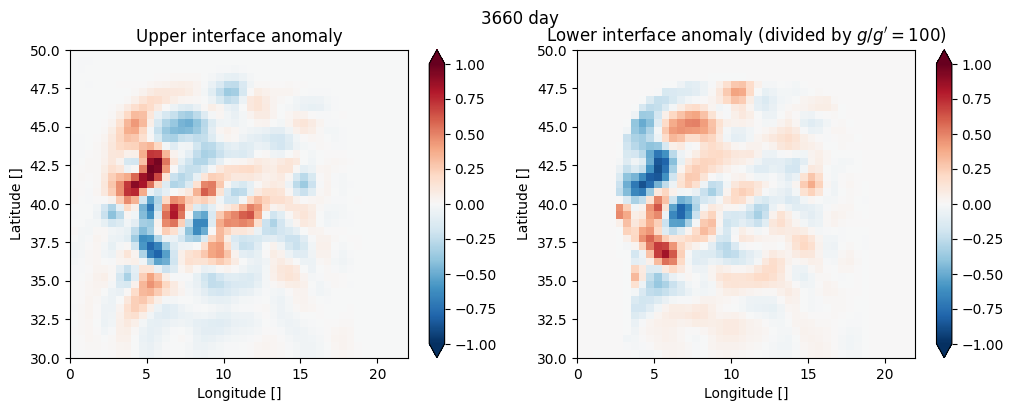

In [7]:
plot()

In [169]:
create_animation_ffmpeg(plot, idx=range(0,100), filename='interface_variability_hires.mp4', FPS=12)

Savefig .ffmpeg/interface_variability_hires/frame-0.png
Savefig .ffmpeg/interface_variability_hires/frame-1.png
Savefig .ffmpeg/interface_variability_hires/frame-2.png
Savefig .ffmpeg/interface_variability_hires/frame-3.png
Savefig .ffmpeg/interface_variability_hires/frame-4.png
Savefig .ffmpeg/interface_variability_hires/frame-5.png
Savefig .ffmpeg/interface_variability_hires/frame-6.png
Savefig .ffmpeg/interface_variability_hires/frame-7.png
Savefig .ffmpeg/interface_variability_hires/frame-8.png
Savefig .ffmpeg/interface_variability_hires/frame-9.png
Savefig .ffmpeg/interface_variability_hires/frame-10.png
Savefig .ffmpeg/interface_variability_hires/frame-11.png
Savefig .ffmpeg/interface_variability_hires/frame-12.png
Savefig .ffmpeg/interface_variability_hires/frame-13.png
Savefig .ffmpeg/interface_variability_hires/frame-14.png
Savefig .ffmpeg/interface_variability_hires/frame-15.png
Savefig .ffmpeg/interface_variability_hires/frame-16.png
Savefig .ffmpeg/interface_variability_hir

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

# Capturing interface variance in basis of PCAs. Two cases: hires and parameterized in the same basis

In [8]:
interfaces_scaled.shape

(1095, 2, 40, 44)

In [9]:
Nt = interfaces_scaled.shape[0]

In [10]:
X_true = interfaces_scaled.values.reshape(Nt,-1)

In [24]:
X_true.shape

(1095, 3520)

In [ ]:
svd_true = np.linalg.svd(X_true, full_matrices=False)

In [ ]:
print(svd_true.U.shape)
print(svd_true.S.shape)
print(svd_true.Vh.shape)

In [14]:
# Check SVD error
np.abs((X_true - svd_true.U @ np.diag(svd_true.S) @ svd_true.Vh)).max() / np.abs((X_true)).max()

9.65921816417679e-15

Text(0.5, 0.98, 'EOF 1')

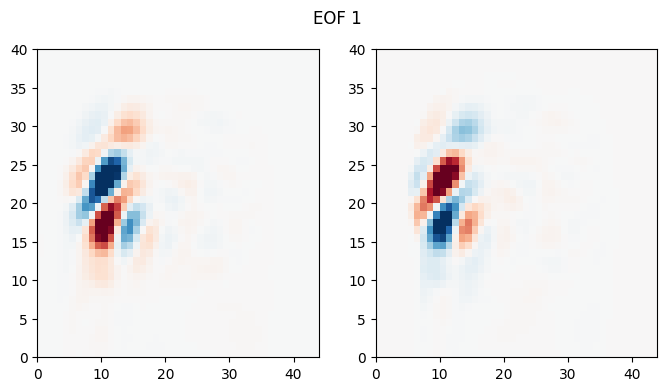

In [15]:
eof = svd_true.Vh[0].reshape(2,40,44)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.pcolormesh(eof[0],cmap='RdBu_r',vmin=-0.1,vmax=0.1)

plt.subplot(1,2,2)
plt.pcolormesh(eof[1],cmap='RdBu_r',vmin=-0.1,vmax=0.1)
plt.suptitle('EOF 1')

Text(0.5, 0.98, 'EOF 2')

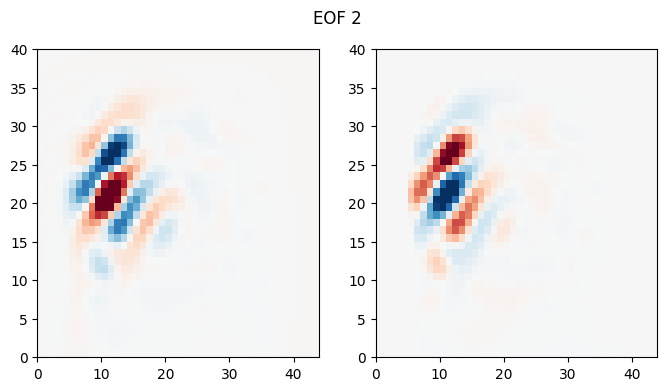

In [16]:
eof = svd_true.Vh[1].reshape(2,40,44)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.pcolormesh(eof[0],cmap='RdBu_r',vmin=-0.1,vmax=0.1)

plt.subplot(1,2,2)
plt.pcolormesh(eof[1],cmap='RdBu_r',vmin=-0.1,vmax=0.1)
plt.suptitle('EOF 2')

Text(0.5, 0.98, 'EOF 3')

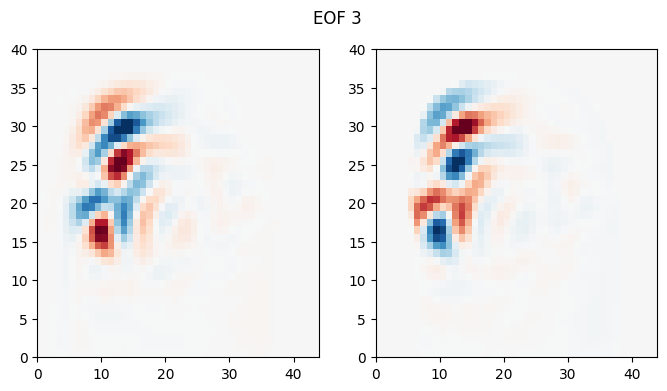

In [18]:
eof = svd_true.Vh[2].reshape(2,40,44)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.pcolormesh(eof[0],cmap='RdBu_r',vmin=-0.1,vmax=0.1)

plt.subplot(1,2,2)
plt.pcolormesh(eof[1],cmap='RdBu_r',vmin=-0.1,vmax=0.1)
plt.suptitle('EOF 3')

# Variance distribution over EOFs
We have the decomposition of the data matrix
$$
X = U \Sigma V^T
$$
The covariance matrix:
$$
C = \frac{1}{N_t} X^T X = \frac{1}{N_t} V \Sigma^2 V^T
$$

Total variance of the signal is:
$$
\langle \sum_{ijk} e_{ijk}'^2 \rangle = \mathrm{tr}(C) = \frac{1}{N_t} \mathrm{tr}(\Sigma^2)
$$

Thus, the variance power spectrum which is independent on the number of time snapshots is
$$
P = \frac{1}{N_t} \mathrm{diag}(\Sigma^2)
$$

In [19]:
# squared second norm over space and mean over time
(X_true**2).sum(axis=1).mean(0)

77.82148904098062

Here we check Parseval identity. Summation of variance of the spatial coordinate should be equal to summation of variance over the EOF number

In [20]:
Power = svd_true.S**2 * 1/Nt
Power.sum()

77.82148904098067

Text(0.5, 0, 'EOF number')

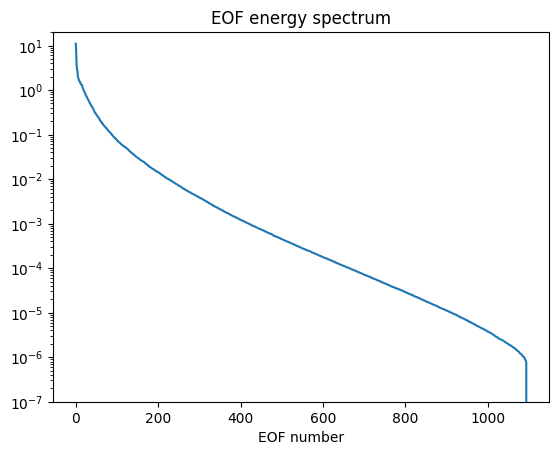

In [21]:
# The last singular value is zero because we removed mean
plt.plot(Power)
plt.yscale('log')
plt.ylim([1e-7,2e+1])
plt.title('EOF energy spectrum')
plt.xlabel('EOF number')

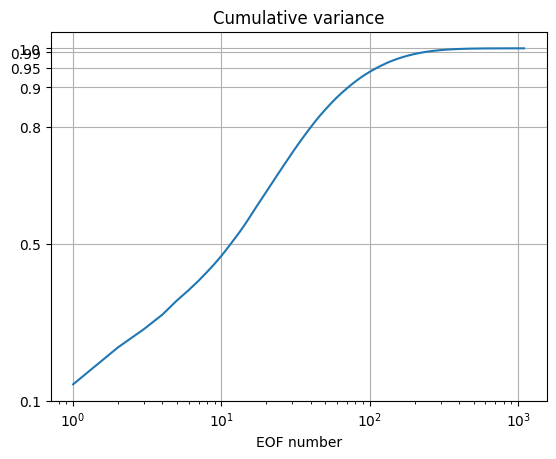

In [22]:
plt.plot(np.arange(1,Nt+1),np.cumsum(Power) / np.sum(Power))
plt.title('Cumulative variance')
plt.xlabel('EOF number')
plt.xscale('log')
plt.yticks([0.1, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0], [0.1, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0])
plt.grid()

# Latest calibrated eANN captures only 60% of variance
Realistically, only 20-ish PCAs is enough to already outperform our baseline

In [23]:
Variance_filtered = (interfaces_scaled**2).sum(['zi','yh','xh']).mean('Time')
Variance_parameterized = (interfaces_parameterized_scaled**2).sum(['zi','yh','xh']).mean('Time')
Variance_parameterized / Variance_filtered

<xarray.DataArray ()> Size: 8B
array(0.58897647)

In [69]:
print(Variance_filtered.values, Variance_parameterized.values)

77.82148904098062 45.83502623475343


# Variance of parameterized model in basis of EOFs of true model
We first start with SVD decomposition of the high-resolution simulation
$$
X_{true} = U_{true} \Sigma_{true} V_{true}^T
$$
Here, matrix $V_{true}^T$ represents a change of basis. We can use this matrix to implement change of basis of the data matrix.
$$
Y_{true} = X_{true} V_{true} = U_{true} \Sigma_{true}
$$
Here, $Y_{true}$ is the new data matrix in transofrmed PCA space with first dimension showing time index, and second dimension showing the number of PCA component
$$
Y_{true} \in \mathbb{R}^{N_t \times N_{\mathrm{PCAs}}}
$$

In [34]:
Y_true = X_true @ svd_true.Vh.T

In [35]:
# Note that by construction number of time snapshots and the number of PCAs are equal
Y_true.shape

(1095, 1095)

Text(0.5, 1.0, 'EOF 3 time series')

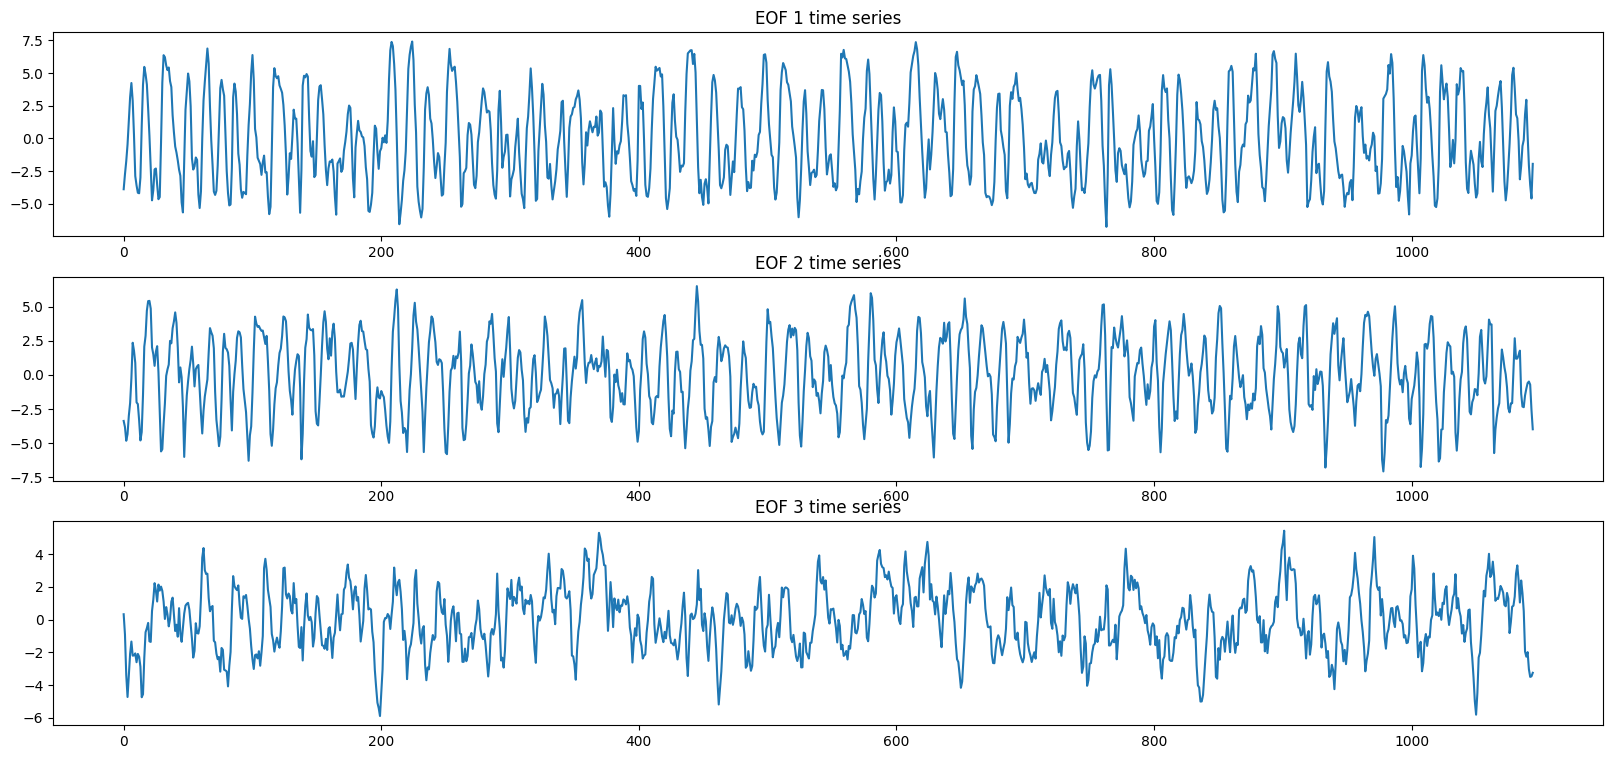

In [48]:
plt.figure(figsize=(20,9))
plt.subplot(3,1,1)
plt.plot(Y_true[:,0])
plt.title('EOF 1 time series')

plt.subplot(3,1,2)
plt.plot(Y_true[:,1])
plt.title('EOF 2 time series')

plt.subplot(3,1,3)
plt.plot(Y_true[:,2])
plt.title('EOF 3 time series')

# EOF timeseries should have variance given by the diagonal of SVD
That is
$$
Var(Y_{true}, axis=Time) = \frac{1}{N_t} \mathrm{diag}(Y_{true}^T Y_{true}) = \frac{1}{N_t} \mathrm{diag}(\Sigma)
$$

In [54]:
np.linalg.norm(Y_true.var(0) - Power)

1.1687723879076928e-14

In [60]:
np.linalg.norm(1/Nt*np.diag(Y_true.T@Y_true) - Power)

1.2031748596990064e-14

# Method to compute power spectrum of parameterized model in spectrum of EOFs of high-resolution simulation
* Convert the data matrix of parameterized model to basis of PCAs of high resolution simulation
$$
Y_{param} = X_{param} V_{true}
$$
* Power spectrum of parameterized model:
$$
P_{param} = \frac{1}{N_t}Y_{param}^TY_{param}
$$

In [62]:
X_param = interfaces_parameterized_scaled.values.reshape(Nt,-1)

In [63]:
Y_param = X_param @ svd_true.Vh.T

In [64]:
Power_param = 1/Nt*np.diag(Y_param.T@Y_param)

In [110]:
# Spatial white noise model for comparison
noise_model = np.random.randn(*X_true.shape) * float(np.sqrt(Variance_filtered) / np.sqrt(X_true.shape[1]))
Y_noise = noise_model @ svd_true.Vh.T
Power_noise = 1/Nt*np.diag(Y_noise.T@Y_noise)

In [111]:
(noise_model**2).sum(1).mean(0)

77.7926682790384

In [112]:
(X_true**2).sum(1).mean(0)

77.82148904098062

# Subsamples of true data to approximately know confidence bounds

In [152]:
Nt_short = 121 # Short trajectory of 10 years
ts = int(np.random.choice(Nt-Nt_short,1)); te = ts + Nt_short
X_true_sample1 = X_true[ts:te]
ts = int(np.random.choice(Nt-Nt_short,1)); te = ts + Nt_short
X_true_sample2 = X_true[ts:te]
ts = int(np.random.choice(Nt-Nt_short,1)); te = ts + Nt_short
X_true_sample3 = X_true[ts:te]

In [153]:
Y_true_sample1 = X_true_sample1 @ svd_true.Vh.T
Y_true_sample2 = X_true_sample2 @ svd_true.Vh.T
Y_true_sample3 = X_true_sample3 @ svd_true.Vh.T

In [154]:
Power_true_sample1 = 1/Nt_short*np.diag(Y_true_sample1.T@Y_true_sample1)
Power_true_sample2 = 1/Nt_short*np.diag(Y_true_sample2.T@Y_true_sample2)
Power_true_sample3 = 1/Nt_short*np.diag(Y_true_sample3.T@Y_true_sample3)

# Basis can be efficiently used to reconstruct full variance of parameterized model

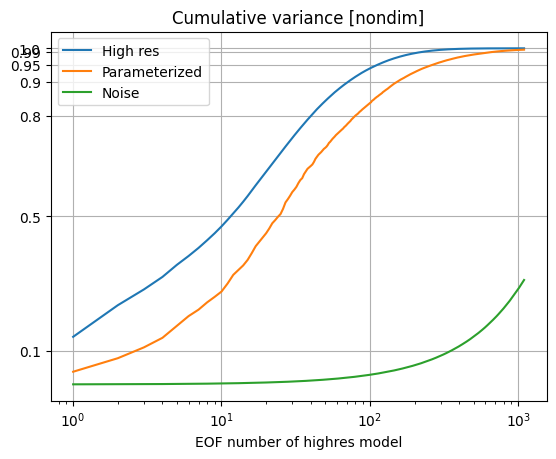

In [115]:
plt.plot(np.arange(1,Nt+1),np.cumsum(Power) / np.sum(Power), label='High res')
plt.plot(np.arange(1,Nt+1),np.cumsum(Power_param) / (X_param**2).sum(1).mean(0), label='Parameterized')
plt.plot(np.arange(1,Nt+1),np.cumsum(Power_noise) / (noise_model**2).sum(1).mean(0), label='Noise')
plt.title('Cumulative variance [nondim]')
plt.xlabel('EOF number of highres model')
plt.xscale('log')
plt.yticks([0.1, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0], [0.1, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0])
plt.grid()
plt.legend()

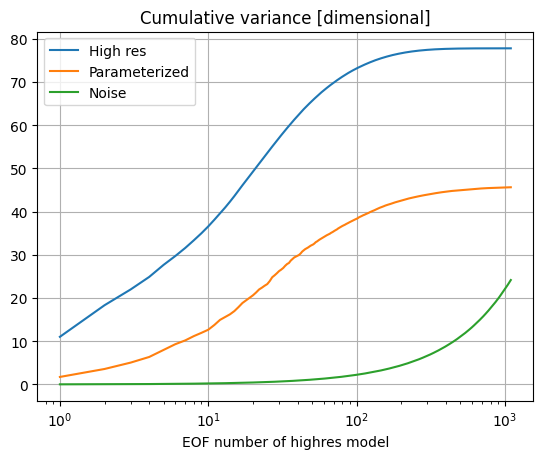

In [117]:
plt.plot(np.arange(1,Nt+1),np.cumsum(Power), label='High res')
plt.plot(np.arange(1,Nt+1),np.cumsum(Power_param), label='Parameterized')
plt.plot(np.arange(1,Nt+1),np.cumsum(Power_noise), label='Noise')
plt.title('Cumulative variance [dimensional]')
plt.xlabel('EOF number of highres model')
plt.xscale('log')
#plt.yticks([0.1, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0], [0.1, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0])
plt.grid()
plt.legend()

Text(0, 0.5, 'Energy per EOF component \nof high-resolution model')

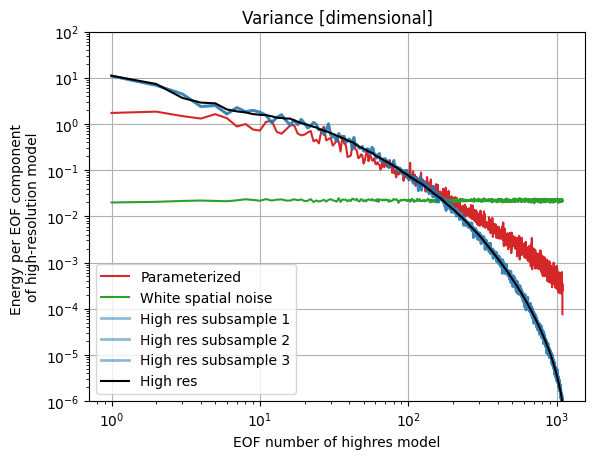

In [159]:
plt.plot(np.arange(1,Nt+1),(Power_param), label='Parameterized', color='tab:red')
plt.plot(np.arange(1,Nt+1),(Power_noise), label='White spatial noise', color='tab:green')
plt.plot(np.arange(1,Nt+1), Power_true_sample3, label='High res subsample 1', color='tab:blue', alpha=0.5, lw=2)
plt.plot(np.arange(1,Nt+1), Power_true_sample3, label='High res subsample 2', color='tab:blue', alpha=0.5, lw=2)
plt.plot(np.arange(1,Nt+1), Power_true_sample3, label='High res subsample 3', color='tab:blue', alpha=0.5, lw=2)
plt.plot(np.arange(1,Nt+1),(Power), label='High res', color='k')
plt.title('Variance [dimensional]')
plt.xlabel('EOF number of highres model')
plt.xscale('log')
#plt.yticks([0.1, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0], [0.1, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0])
plt.grid()
plt.legend()
plt.yscale('log')
plt.ylim([1e-6,1e+2])
plt.ylabel('Energy per EOF component \nof high-resolution model')